## CS436/5310/EE513 - Fall 2025 - PA3 - Part 1 - (50 Marks)

#### Important Instructions and Submission Guidelines:
- Naming convention for submission of this notebook is `RollNumber_PA3_Part1.ipynb` where. For example: `26100277_PA3_Part1.ipynb`
- All the cells <b>must</b> be run once before submission. If your submission's cells are not showing the results (plots etc.), marks will be deducted
- Only the code written within this notebook's marked areas will be considered while grading. No other files will be entertained
- You are advised to follow good programming practies including approriate variable naming and making use of logical comments 


The university honor code should be maintained. Any violation, if found, will result in disciplinary action. 

In [28]:
# making all necessary imports here
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# if you have to make any imports, do so here

### Task 1 — Camera Projection 
In this task, you will be exploring different variations for camera setups, by varying the extrinsic and intrinsic parameters.


1) Load the 3d points from `lego_model.mat`
2) Visualize the 3D Model
3) Take images of the model with different camera setups

<b>Note:</b> Code for loading the point cloud and visualizing it has been given to you. Further build on it and take images of the model and visualize them

In [29]:
# function to load the 3d model
def load_model(file_path):
    # Load teapot data
    data =loadmat(file_path)
    return data['verts']
    

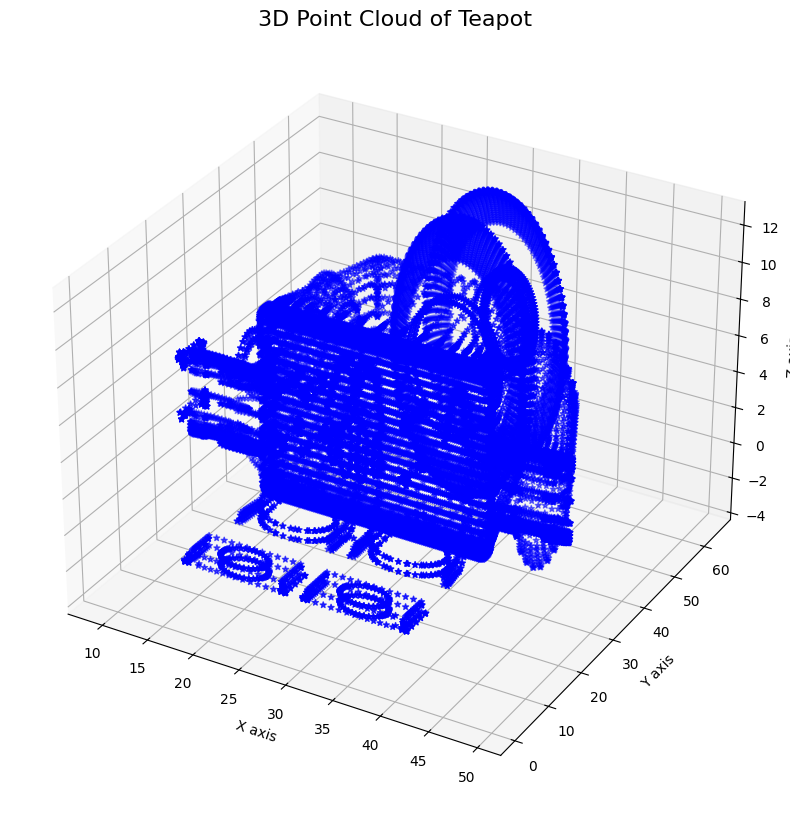

In [30]:
x = load_model('lego_model.mat')
# extracting points(coordinates) from vertices
a = []
b = []
c = []
for points in x:
    # print(points)
    a.append(points[0])
    b.append(points[1])
    c.append(points[2])

# 3D plotting the extracted points
fig = plt.figure(figsize=(12, 10))


ax = fig.add_subplot(111, projection='3d')

ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('3D Point Cloud of Teapot', fontsize=16)

ax.scatter(a,b,c, c='b', marker='*')
# print (len(a))

### Define Helper Functions to setup the Camera Matrix and VIsualization of Results

1) You may define any helper functions you deem necessary.
2) Functions to visualize the results are already provided. Make sure to only use these functions to view your results.

 <b>Hint: </b> 2Dpoints = K[R|T]*3DPoints

In [31]:
pts =[]
pts.append(a)
pts.append(b)
pts.append(c)
pts=np.array(pts)
pts=pts.T

### Helper Functions 

- A helper function to visualize your images is provided below: `visualize_points`.
- You may make other helper functions here as per your need

In [32]:
def visualize_points(all_projected, all_captions):

    """
    Visualize 2D points for different images with global axis scaling.

    all_projected - list of 2d points for each image (each element is an image)
    all_captions - list of captions for each image
    """
    # Calculate global xlim and ylim for all points
    all_points = np.vstack(all_projected)
    x_min, x_max = all_points[:, 0].min(), all_points[:, 0].max()
    y_min, y_max = all_points[:, 1].min(), all_points[:, 1].max()
    x_pad = (x_max - x_min) * 0.1  # 10% padding
    y_pad = (y_max - y_min) * 0.1
    xlim = [x_min - x_pad, x_max + x_pad]
    ylim = [y_min - y_pad, y_max + y_pad]
    plt.figure(figsize=(18, 6))
    # Plot each focal length in a subplot
    for i, (f, projected) in enumerate(zip(all_captions, all_projected), 1):
        plt.subplot(1, len(all_captions), i)
        plt.scatter(projected[:, 0], projected[:, 1], c='b', marker='.', s=1)
        plt.title(f)
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.grid(True)
        plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()





### Scenario 1: Exploring the Impact of Focal Length (10 Marks)

Imagine a photographer capturing a LEGO figure at different focal lengths to examine how the perceived size and depth change without moving the camera. In this task, you'll simulate this scenario by projecting a set of 3D points at varying focal lengths.

#### Objective

Using three distinct focal lengths—400mm, 800mm, and 1600mm—project a set of 3D points representing the LEGO figure onto a 2D plane. Assume the camera's position and orientation remain fixed for each focal length.

- <b>Camera Position:</b> For simplicity, we’ll assume the camera is positioned directly along the z-axis at [-1000], so it’s 1000 units away from the LEGO figure. This default translation keeps the camera stationary across focal lengths and emphasizes the effect of focal length alone.

#### Task

Implement the function `scenario_1_varying_focal_length(pts)` with the following goals:
- Use the provided focal lengths to create a projection matrix for each case.
- Project the points in pts and visualize the 2D projections.

Visualize the results using `visualize_points()` to examine the differences. Observe how focal length influences the projection, creating the illusion of the LEGO figure’s size and depth changing even though the camera position is the same.

<b>Reflection</b>: Briefly comment on how varying the focal length affects the field of view, scale, and depth of the projection.



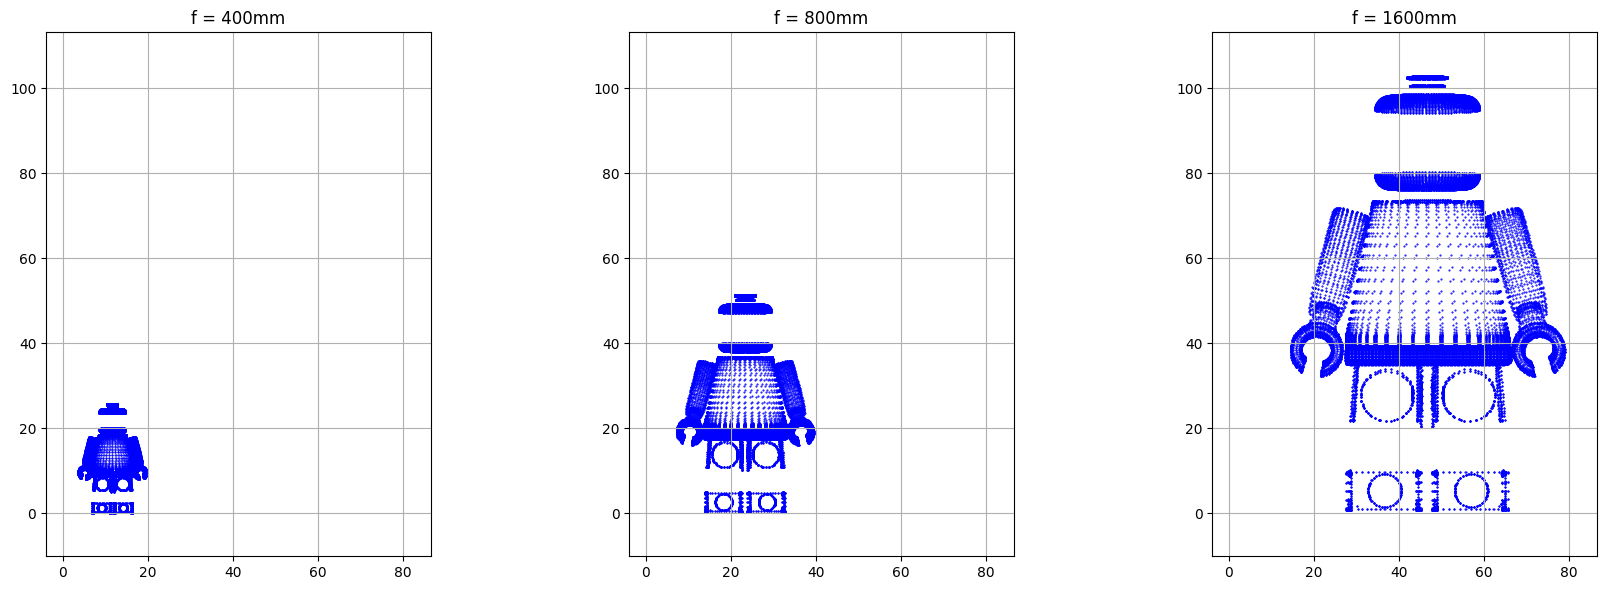

In [33]:
def scenario_1_varying_focal_length(pts):
    """
    Scenario 1: Compare different focal lengths.
    Projects 3D points (pts) using a fixed camera position
    and varying focal lengths.

    Args:
        pts (np.ndarray): The 3D points to project, shape (N, 3).
    """

    # List to store results for visualization
    all_projected = []
    all_captions = []

    # Focal lengths
    focal_lengths = [400, 800, 1600]

    # Prepare 3D points for matrix multiplication
    num_points = pts.shape[0]
    # Transpose to (3, N)
    pts_t = pts.T
    # Add homogeneous coordinate (row of 1s) to get (4, N)
    pts_homo = np.vstack((pts_t, np.ones(num_points)))

    # Extrinsic Parameters [R|T]
    R = np.eye(3)

    # T: Translation Vector (3x1).
    T = np.array([[0], [0], [1000]])

    # Combine R and T into the extrinsic matrix [R|T] (3x4)
    E = np.hstack((R, T))

    for f in focal_lengths:
        K = np.array([
            [f, 0, 0],
            [0, f, 0],
            [0, 0, 1]
        ])

        # Create the full Projection Matrix P = K[R|T] (3x4)
        P = K @ E

        # Project 3D points to 2D
        # (3x4) @ (4, N) = (3, N)
        projected_homo = P @ pts_homo

        # Perform perspective division (Homogeneous to 2D)
        w = projected_homo[2, :]
        u = np.divide(projected_homo[0, :], w,
                      out=np.zeros_like(projected_homo[0, :]), where=w!=0)
        v = np.divide(projected_homo[1, :], w,
                      out=np.zeros_like(projected_homo[1, :]), where=w!=0)
        projected_2d = np.vstack((u, v)).T

        all_projected.append(projected_2d)
        all_captions.append(f'f = {f}mm')
    visualize_points(all_projected, all_captions)

# --- Example Usage ---
file_path = 'lego_model.mat'
pts_3d = load_model(file_path)
scenario_1_varying_focal_length(pts_3d)


#### Effect of focal length on the field of view, scale, and depth of the projection

**1. Field of View**
- **Small focal length (f = 400)**: Wider field of view → object appears smaller.
- **Large focal length (f = 1600)**: Narrow field of view → zoomed‐in appearance.

**2. Scale**
Increasing f directly increases image coordinates, making the projection appear larger.

**3. Depth perception**
- Larger f makes depth differences less noticeable (more “orthographic‐like”).
- Smaller f exaggerates perspective differences (stronger perspective distortion).

### Scenario 2: Exploring the Effect of Camera Position (10 Marks)

In this scenario, imagine shifting a camera around a LEGO figure to see how changes in the camera’s position alter the perspective of the figure. Unlike Scenario 1, where focal length changed with a fixed camera position, here the focal length remains constant while the camera moves to new positions. This approach will help you observe how camera position affects the scene.

#### Objective
Using a focal length of 1200mm, project a set of 3D points representing the LEGO figure from three different camera positions:
- **Center**: Camera positioned directly along the z-axis at `(0, 0, -1000)`.
- **Right**: Camera shifted 200 units to the right, to `(200, 0, -1000)`.
- **Up**: Camera moved 200 units upward, to `(0, 200, -1000)`.

#### Task
1. Implement the function `scenario_2_camera_positions(pts)` with the following goals:
   - Use the fixed focal length and specified camera positions to create projection matrices for each position.
   - Project the points in `pts` and visualize the 2D projections.
   
2. **Visualize** the results using `visualize_points()` to analyze the differences. Notice how the perspective changes as the camera moves to different locations while keeping its focus on the LEGO figure.

3. **Reflection**: Briefly comment on how shifting the camera position affects the perceived orientation and positioning of the figure, compared to changing only the focal length in Scenario 1.

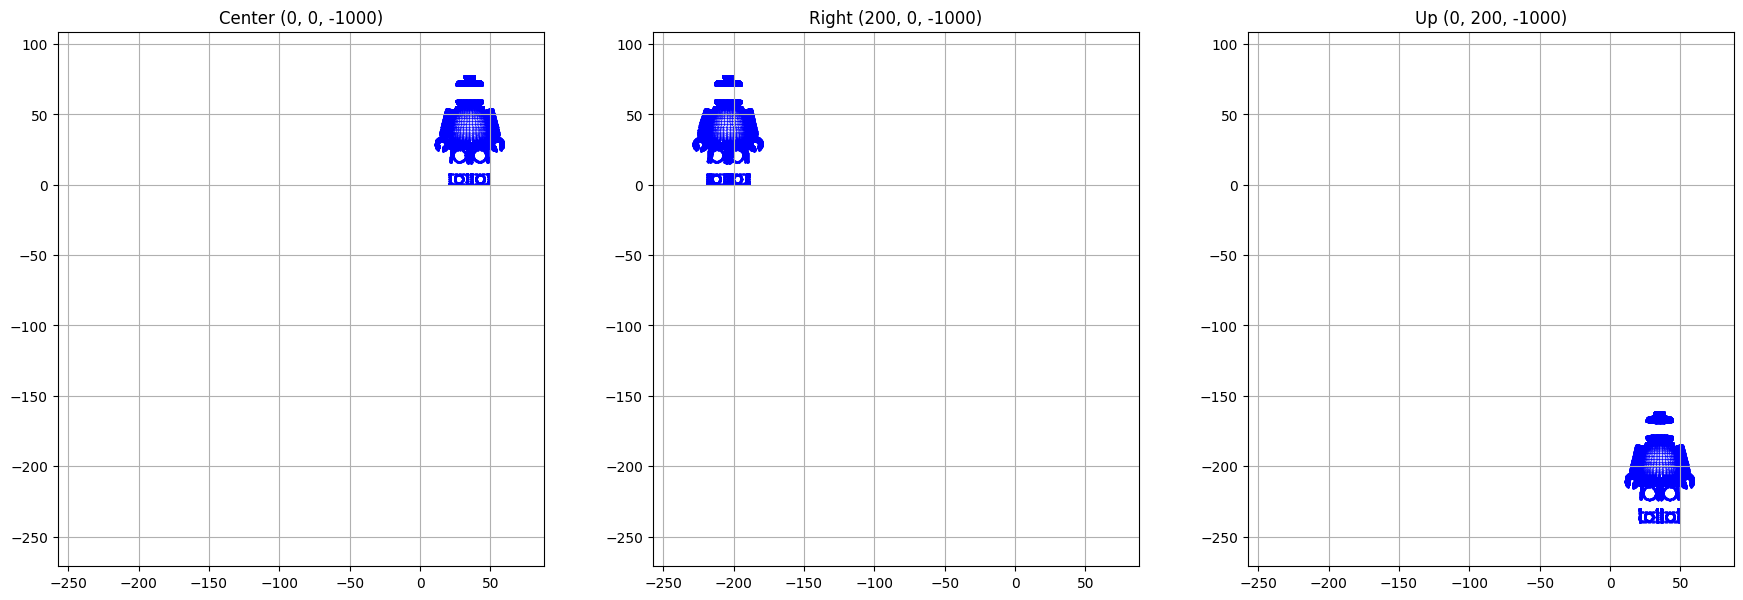

In [34]:
def scenario_2_camera_positions(pts):
    """
    Scenario 2: Compare different camera positions with a fixed focal length.

    Args:
        pts (np.ndarray): The 3D points to project, shape (N, 3).
    """
    all_projected = []
    all_captions = []

    # fixed parameters
    f = 1200  # Fixed focal length

    # intrinsic Matrix K (3x3)
    K = np.array([
        [f, 0, 0],
        [0, f, 0],
        [0, 0, 1]
    ])

    # fixed Rotation R (Identity, camera is not tilted)
    R = np.eye(3)
    positions = [
        {'C_world': np.array([[0], [0], [-1000]]), 'caption': 'Center (0, 0, -1000)'},
        {'C_world': np.array([[200], [0], [-1000]]), 'caption': 'Right (200, 0, -1000)'},
        {'C_world': np.array([[0], [200], [-1000]]), 'caption': 'Up (0, 200, -1000)'}
    ]
    num_points = pts.shape[0]
    pts_homo = np.vstack((pts.T, np.ones(num_points)))
    for pos in positions:
        C = pos['C_world']
        caption = pos['caption']
        T = -R @ C
        E = np.hstack((R, T))
        P = K @ E
        projected_homo = P @ pts_homo
        w = projected_homo[2, :]
        u = np.divide(projected_homo[0, :], w,
                      out=np.zeros_like(projected_homo[0, :]), where=w!=0)
        v = np.divide(projected_homo[1, :], w,
                      out=np.zeros_like(projected_homo[1, :]), where=w!=0)
        projected_2d = np.vstack((u, v)).T

        all_projected.append(projected_2d)
        all_captions.append(caption)
    visualize_points(all_projected, all_captions)

# --- Example Usage ---
file_path = 'lego_model.mat'
pts_3d = load_model(file_path)
scenario_2_camera_positions(pts_3d)

#### Effect of Camera Position
Moving the camera itself changes the apparent position of the object on the 2D image plane.

- When the camera moves right (to X=200), the LEGO figure appears to shift to the left in the 2D image.
- When the camera moves up (to Y=200), the LEGO figure appears to shift down in the 2D image.

What we are observing here is parallax. The change in the 2D image is not just a simple 2D translation of the "Center" image. Because we are viewing the 3D model from a new position, the relative positions of the points shift. Points on the LEGO figure that are closer to the camera will appear to move more in the 2D image than points that are farther away. This change in viewpoint is fundamentally different from simply zooming in on a fixed viewpoint, as we did in Scenario 1.

### Scenario 3: Telephoto Effect vs. Camera Position (10 Marks)

This scenario demonstrates how both focal length and camera distance from the subject can influence perspective and perceived depth. You’ll explore the telephoto effect by varying the camera’s focal length and positioning it at different distances from the LEGO figure.

#### Objective
With three different setups of focal length and camera distance, observe how changes affect the projection. The three setups include:
- **Close-up**: 600mm focal length with the camera close to the LEGO figure at z = -500 units.
- **Telephoto**: 1800mm focal length with the camera further away at z = -5000 units.
- **Medium**: 1200mm focal length with the camera positioned at z = -1000 units.

#### Task
1. Implement `scenario_3_telephoto_vs_position(pts)` with the following steps:
   - For each setup, create the appropriate projection matrix and project the points in `pts`.
   - Visualize the projections with `visualize_points()` to analyze how each setup affects the appearance of the LEGO figure.

2. **Reflection**: Briefly comment on the differences in projection. How does the telephoto setup compare to the close-up, and what effect does it have on perceived scale and depth?

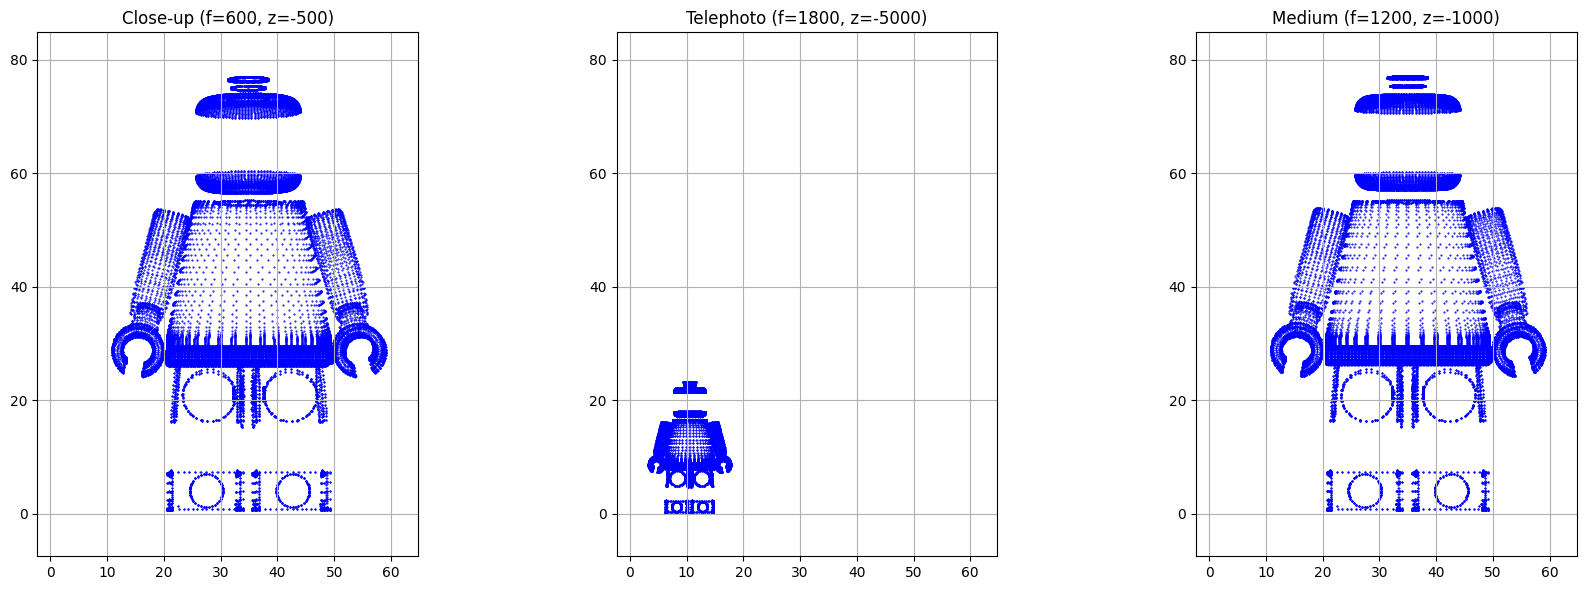

In [35]:
def scenario_3_telephoto_vs_position(pts):
    """
    Scenario 3: Compare setups varying both focal length and
    camera distance.

    Args:
        pts (np.ndarray): The 3D points to project, shape (N, 3).
    """

    all_projected = []
    all_captions = []
    # Each setup has a focal length (f) and a camera Z-position (C_z)
    setups = [
        {'f': 600, 'C_z': -500, 'caption': 'Close-up (f=600, z=-500)'},
        {'f': 1800, 'C_z': -5000, 'caption': 'Telephoto (f=1800, z=-5000)'},
        {'f': 1200, 'C_z': -1000, 'caption': 'Medium (f=1200, z=-1000)'}
    ]
    # Convert (N, 3) to (4, N) homogeneous coordinates
    num_points = pts.shape[0]
    pts_homo = np.vstack((pts.T, np.ones(num_points)))
    R = np.eye(3)

    for setup in setups:
        f = setup['f']
        C_z = setup['C_z']
        caption = setup['caption']

        K = np.array([
            [f, 0, 0],
            [0, f, 0],
            [0, 0, 1]
        ])

        # C is the camera's position in world coordinates
        C_world = np.array([[0], [0], [C_z]])
        # T is the world's position relative to the camera (T = -R * C)
        T = -R @ C_world
        E = np.hstack((R, T))
        P = K @ E
        projected_homo = P @ pts_homo

        w = projected_homo[2, :]
        u = np.divide(projected_homo[0, :], w,
                      out=np.zeros_like(projected_homo[0, :]), where=w!=0)
        v = np.divide(projected_homo[1, :], w,
                      out=np.zeros_like(projected_homo[1, :]), where=w!=0)
        projected_2d = np.vstack((u, v)).T

        all_projected.append(projected_2d)
        all_captions.append(caption)

    visualize_points(all_projected, all_captions)

file_path = 'lego_model.mat'
pts_3d = load_model(file_path)
scenario_3_telephoto_vs_position(pts_3d)

#### Telephoto Effect vs. Camera Position

**Perceived Depth (Perspective):**
    - Close-up (f=600, z=-500): This wide-angle, close-up shot exaggerates perspective. Points on the LEGO figure closer to the camera look much larger relative to points farther away, creating a "warped" or "in-your-face" look.
    - Telephoto (f=1800, z=-5000): This setup compresses perspective, creating the classic "telephoto flattening" effect. Because the camera is so far away, the relative distance between the figure's front and back is tiny, making the 2D image look "flat."

**Perceived Scale (Magnification):** The projected "size" is roughly determined by the ratio f / |z|:
    - Close-up: 600 / 500 = 1.2
    - Medium: 1200 / 1000 = 1.2
    - Telephoto: 1800 / 5000 = 0.36

This shows that the Close-up and Medium setups produce a similarly sized figure. The Telephoto setup, despite its long focal length, produces a much smaller image because the camera is so far away.


### Scenario 4: Matching Perspective with Different Focal Lengths (10 Marks)

In this challenge, you'll experiment with achieving the same projected image at different focal lengths by adjusting the camera's distance.

#### Objective
Given an initial setup with a large focal length (e.g., 5000mm) and the camera positioned far from the LEGO figure (e.g., z = -5000 units), calculate the required **translation** to replicate the same projection if the focal length is reduced to 500mm.

#### Task
1. Implement `scenario_4_calculate_translation(pts)`, and determine the new camera position required to achieve the same image projection at a focal length of 500mm.
2. Use `visualize_points()` to confirm that the projection with the calculated translation closely matches the original setup with a 5000mm focal length.

3. **Reflection**: Comment on the relationship between focal length and camera distance. What general rule can you deduce for achieving the same projection with different focal lengths?


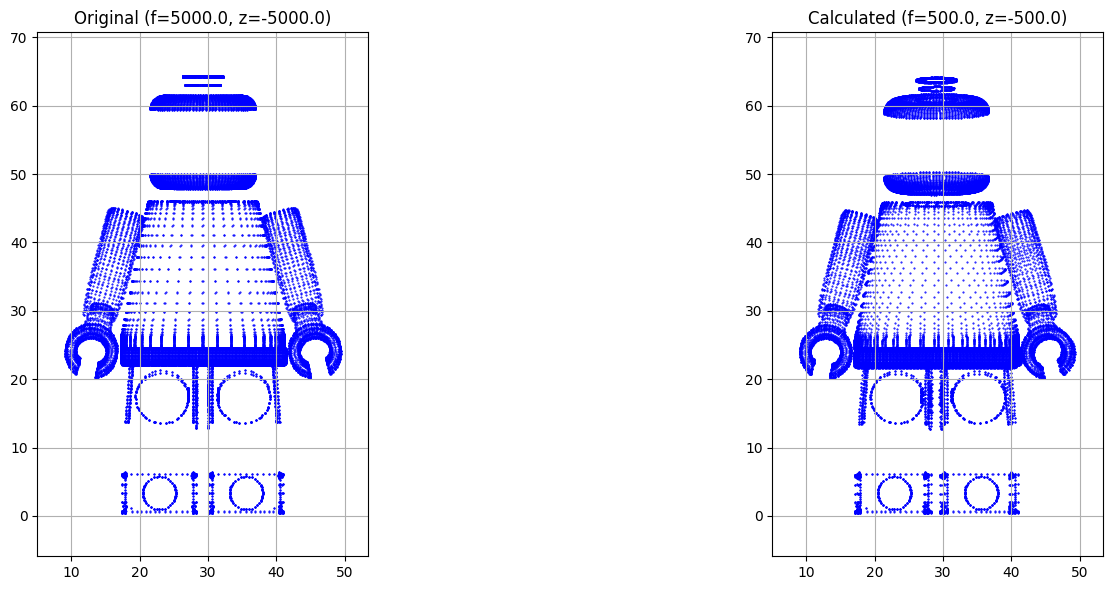

In [36]:
def scenario_4_calculate_translation(pts):
    """
    Scenario 4: Calculate the new camera position to match the
    projected scale of an object given a new focal length.

    Args:
        pts (np.ndarray): The 3D points to project, shape (N, 3).
    """
    all_projected = []
    all_captions = []
    f1 = 5000.0

    T1 = np.array([[0], [0], [5000.0]])
    f2 = 500.0
    D1 = T1[2, 0]
    D2 = f2 * (D1 / f1)
    T2 = np.array([[0], [0], [D2]])
    num_points = pts.shape[0]
    pts_homo = np.vstack((pts.T, np.ones(num_points)))
    R = np.eye(3)
    setups = [
        {'f': f1, 'T': T1, 'caption': f'Original (f={f1}, z={-D1})'},
        {'f': f2, 'T': T2, 'caption': f'Calculated (f={f2}, z={-D2})'}
    ]

    for setup in setups:
        f = setup['f']
        T = setup['T']
        caption = setup['caption']
        K = np.array([
            [f, 0, 0],
            [0, f, 0],
            [0, 0, 1]
        ])
        E = np.hstack((R, T))
        P = K @ E
        projected_homo = P @ pts_homo
        w = projected_homo[2, :]
        u = np.divide(projected_homo[0, :], w,
                      out=np.zeros_like(projected_homo[0, :]), where=w!=0)
        v = np.divide(projected_homo[1, :], w,
                      out=np.zeros_like(projected_homo[1, :]), where=w!=0)
        projected_2d = np.vstack((u, v)).T
        all_projected.append(projected_2d)
        all_captions.append(caption)
    visualize_points(all_projected, all_captions)

file_path = 'lego_model.mat'
pts_3d = load_model(file_path)
scenario_4_calculate_translation(pts_3d)


#### Matching Perspective with Different Focal Lengths

We reduced the focal length by a factor of 10 (from 5000mm to 500mm).
To compensate and keep the LEGO figure the same size, we had to also reduce the camera's distance by a factor of 10 (from 5000 units to 500 units).
5000 / 5000 = 1
500 / 500 = 1

The visualization confirms this: both projections are the same size.

Crucial Nuance (Scale vs. Perspective): While this keeps the scale the same, the perspective is not the same.
- The f=5000, D=5000 shot is taken from far away, resulting in strong perspective compression (a "flat" image).

- The f=500, D=500 shot is taken much closer, resulting in perspective exaggeration (a "deeper," more "warped" image).

This technique of changing f and D together to maintain scale while purposefully changing the perspective's "compression" is known as a dolly zoom (or "Vertigo effect") in filmmaking.

### Scenario 5: Exploring the Impact of Camera Rotation (10 Marks)

This scenario allows you to observe how varying only the camera rotation (without altering focal length or camera distance) affects the projected image of the LEGO figure. You’ll explore different rotation angles around the Y-axis to see how each one changes the appearance of the subject.

#### Objective
By comparing projections at different rotations, you’ll understand how orientation alone impacts perspective, without modifying the camera's distance or focal length.

#### Setups
We’ll keep the focal length fixed at 1200mm and the camera positioned at \( z = -1000 \) units from the LEGO figure. The following rotation angles are used:
- **0°**: The camera directly faces the subject.
- **30°**: A slight rotation to the right.
- **60°**: A more pronounced rotation.
- **90°**: A side-on view with the camera positioned perpendicular to the subject.

#### Task
1. Implement `scenario_5_varying_rotation(pts)` by following these steps:
   - For each rotation angle, construct the rotation matrix and projection matrix.
   - Project the points using each setup and visualize them with `visualize_points()` to assess how each orientation impacts the figure’s appearance.

2. **Reflection**: Describe the differences in each projection. How does the rotation impact what parts of the LEGO figure are visible? How does rotating the camera change the relative positioning of points within the projection?

By focusing on rotation alone, this scenario highlights the effects of changing the camera’s orientation on perceived depth and perspective, emphasizing the role of angle in shaping the viewer's experience without any zoom or position changes.

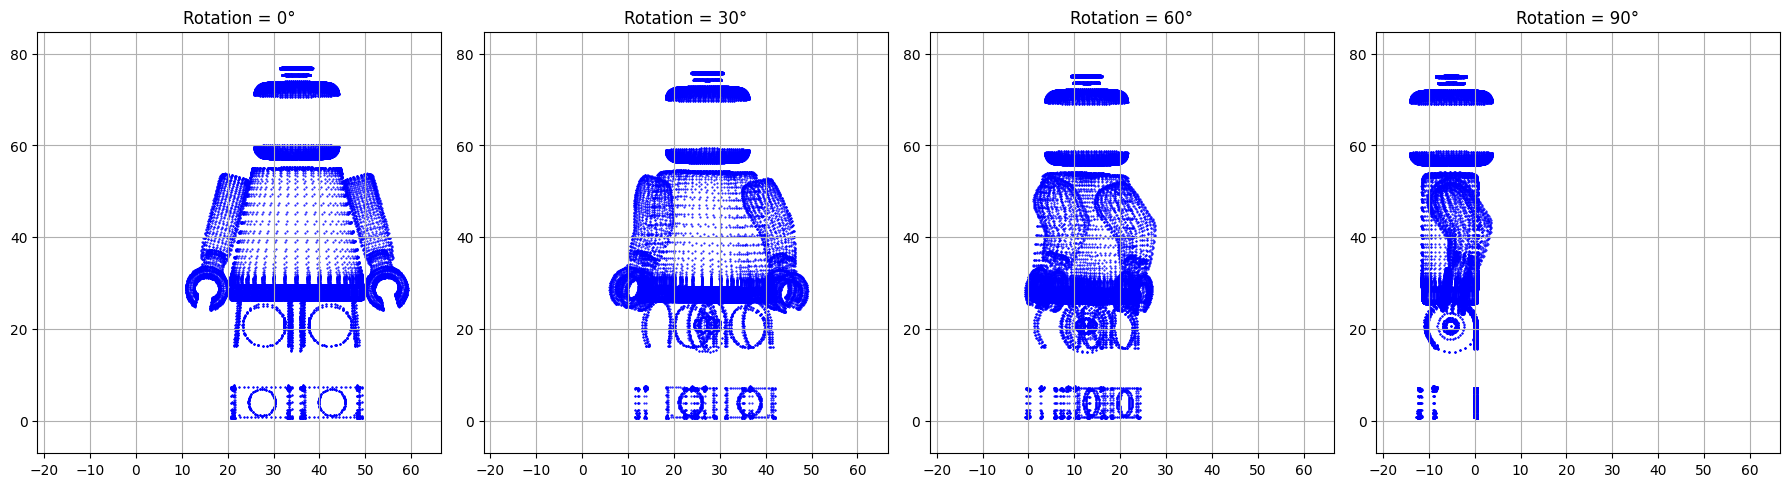

In [38]:
def get_rotation_y(theta_deg):
    """
    Calculates the 3x3 rotation matrix for a rotation
    around the Y-axis.

    Args:
        theta_deg (float): Angle in degrees.

    Returns:
        np.ndarray: The 3x3 rotation matrix.
    """
    theta_rad = np.radians(theta_deg)
    c = np.cos(theta_rad)
    s = np.sin(theta_rad)
    return np.array([
        [c,  0,  s],
        [0,  1,  0],
        [-s, 0,  c]
    ])
def scenario_5_varying_rotation(pts):
    """
    Scenario 5: Compare different camera rotations around the Y-axis.

    Args:
        pts (np.ndarray): The 3D points to project, shape (N, 3).
    """

    all_projected = []
    all_captions = []

    f = 1200
    C_world = np.array([[0], [0], [-1000]])

    K = np.array([
        [f, 0, 0],
        [0, f, 0],
        [0, 0, 1]
    ])
    rotation_angles = [0, 30, 60, 90]
    num_points = pts.shape[0]
    pts_homo = np.vstack((pts.T, np.ones(num_points)))

    T = np.array([[0], [0], [1000]])
    for theta in rotation_angles:
        R = get_rotation_y(theta).T
        E = np.hstack((R, T))
        P = K @ E
        projected_homo = P @ pts_homo
        w = projected_homo[2, :]
        u = np.divide(projected_homo[0, :], w,
                      out=np.zeros_like(projected_homo[0, :]), where=w!=0)
        v = np.divide(projected_homo[1, :], w,
                      out=np.zeros_like(projected_homo[1, :]), where=w!=0)
        projected_2d = np.vstack((u, v)).T

        all_projected.append(projected_2d)
        all_captions.append(f'Rotation = {theta}°')
    visualize_points(all_projected, all_captions)

file_path = 'lego_model.mat'
pts_3d = load_model(file_path)
scenario_5_varying_rotation(pts_3d)


#### Effect of Varying Camera Rotation

- 0°: This is the baseline "front-on" view. The LEGO figure is centered, and we see its front face symmetrically.

- 30°: The camera has rotated, and from its new viewpoint, the figure appears turned. We can now see the front of the figure and its (figure's) right side.

- 60°: The figure appears to be turned even more. We see less of the front and significantly more of its right side.

- 90°: The figure is now seen in a perfect "side-on" profile. The points that define its front (like its "chest") and back are now at the left and right edges of the 2D projection.

**Impact on Visibility and Positioning:**

- **Changing View, Not Position:** Unlike Scenario 2 (where the camera moved left/right), rotating the camera doesn't just shift the object in the frame. It fundamentally changes the viewpoint.

- **Revealing 3D Structure:** Rotation causes a 3D effect. Points on the "front" of the figure move across the 2D image in one direction, while points on the "back" of the figure move in the opposite direction. This change in the relative positioning of points is what gives us the perception of a 3D object turning in space.

- **Visibility:** As the camera rotates, it "sees" around the side of the object. Parts of the figure that were previously occluded (hidden), like its side and the side of its arm, become visible. At 90°, the entire front of the figure is occluded, and only the side profile is visible.

#### Thats it! You're done with PA3 (Part 1). 